In [80]:
#Librerie
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from warnings import filterwarnings
import altair as alt
alt.data_transformers.enable('default', max_rows=None)

DataTransformerRegistry.enable('default')

In [81]:
filterwarnings("ignore")

In [82]:
#Definizione di funzioni per calcolare sse, bss e le performance di clusteirng
def get_sse(X, labels):
    sse = 0
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        sse += np.sum(cdist(np.expand_dims(c, axis=0), X[labels == l]) ** 2)
    return sse


def get_bss(X, labels):
    cluster_centers = list()
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        cluster_centers.append(c)
    cluster_centers = np.array(cluster_centers)
    _, sizes = np.unique(labels, return_counts=True)
    m = np.mean(X, axis=0)
    bss = np.sum(sizes * cdist(np.expand_dims(m, axis=0), cluster_centers) ** 2)
    return bss


def eval_clustering(X, labels):
    sse = get_sse(X[labels != -1], labels[labels != -1])
    bss = get_bss(X[labels != -1], labels[labels != -1])
    silh = silhouette_score(X[labels != -1], labels[labels != -1])
    return sse, bss, silh

In [83]:
#Dataset necessari
df_macro = pd.read_csv("Macro_sports.csv")
df_success = pd.read_csv("Success_score_country_sport.csv")

In [84]:
#Creo un profilo aggregato per ogni paese, calcolando su tutte le edizioni olimpiche:
# - total_gold, total_silver, total_bronze, total_medals: medaglie totali per tipo
# - n_sports: numero di sport diversi in cui il paese ha gareggiato
# - n_editions: numero di edizioni olimpiche a cui il paese ha partecipato
# - athletes_total: numero totale di atleti inviati nel corso della storia
# - gold_per_athlete_mean: media del rapporto ori/atleti calcolato per ogni sport, poi mediato sul paese
df_country_profile = df_macro.groupby(['country_noc', 'country']).agg(
    total_gold = ('gold', 'sum'),
    total_silver = ('silver', 'sum'),
    total_bronze = ('bronze', 'sum'),
    total_medals = ('total_medals', 'sum'),
    n_sports = ('sport', 'nunique'),
    n_editions = ('year', 'nunique'),
    athletes_total = ('num_athletes', 'sum'),
    gold_per_athlete_mean = ('gold_per_athletes', 'mean')
).reset_index()

In [85]:
#Calcolo feature derivate a livello paese:
# - medals_per_edition: intensità media di successo per edizione
# - gold_ratio: qualità delle medaglie (quanto sono "preziose" in media)
# - gold_per_athlete_agg: efficienza aggregata (a differenza di gold_per_athlete_mean, qui i paesi con più atleti pesano proporzionalmente di più)
df_country_profile['medals_per_edition'] = (
    df_country_profile['total_medals'] / df_country_profile['n_editions']
)

df_country_profile['gold_ratio'] = (
    df_country_profile['total_gold'] / df_country_profile['total_medals']
).fillna(0)

df_country_profile['gold_per_athlete_agg'] = (
    df_country_profile['total_gold'] / df_country_profile['athletes_total']
).fillna(0)

In [86]:
df_country_profile

,country_noc,country,total_gold,total_silver,total_bronze,total_medals,n_sports,n_editions,athletes_total,gold_per_athlete_mean,medals_per_edition,gold_ratio,gold_per_athlete_agg
0,AFG,Afghanistan,0,0,2,2,7,11,62,0.000000,0.181818,0.000000,0.000000
1,AHO,Netherlands Antilles,0,1,0,1,10,11,50,0.000000,0.090909,0.000000,0.000000
2,ALG,Algeria,5,4,8,17,23,14,547,0.005239,1.214286,0.294118,0.009141
3,ARG,Argentina,8,10,19,37,43,14,1868,0.005948,2.642857,0.216216,0.004283
4,ARM,Armenia,2,8,8,18,14,7,174,0.004032,2.571429,0.111111,0.011494
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,VEN,Venezuela,3,7,7,17,34,15,664,0.003623,1.133333,0.176471,0.004518
140,VIE,Vietnam,1,3,1,5,17,10,149,0.007143,0.500000,0.200000,0.006711
141,YUG,Yugoslavia,21,19,25,65,25,7,832,0.036744,9.285714,0.323077,0.025240
142,ZAM,Zambia,0,1,1,2,8,14,199,0.000000,0.142857,0.000000,0.000000


In [87]:
df_country_profile.describe()

,total_gold,total_silver,total_bronze,total_medals,n_sports,n_editions,athletes_total,gold_per_athlete_mean,medals_per_edition,gold_ratio,gold_per_athlete_agg
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,26.173611,26.118056,29.284722,81.576389,22.854167,11.562500,897.270833,0.015123,8.967423,0.227216,0.016891
std,65.991346,56.170631,56.139395,176.811487,13.250132,3.594321,1242.565259,0.020870,20.649578,0.183257,0.023600
min,0.000000,0.000000,0.000000,1.000000,3.000000,1.000000,19.000000,0.000000,0.066667,0.000000,0.000000
25%,0.000000,1.000000,1.000000,3.000000,12.750000,8.750000,158.000000,0.000000,0.245192,0.000000,0.000000
50%,3.000000,5.000000,7.500000,15.500000,20.000000,13.000000,354.000000,0.007728,1.325000,0.250000,0.010753
75%,21.250000,21.250000,26.000000,70.250000,32.000000,14.000000,1036.500000,0.018789,5.785714,0.329365,0.022483
max,589.000000,481.000000,430.000000,1500.000000,55.000000,15.000000,7444.000000,0.141955,122.666667,1.000000,0.157895


In [88]:
# Per l'analisi di clustering mantengo solo i paesi che hanno vinto almeno 10 medaglie totali nel corso delle Olimpiadi
df_country_profile = df_country_profile[df_country_profile['total_medals'] >= 10]
print(df_country_profile.shape)

(79, 13)


In [89]:
df_country_profile.columns

Index(['country_noc', 'country', 'total_gold', 'total_silver', 'total_bronze',
       'total_medals', 'n_sports', 'n_editions', 'athletes_total',
       'gold_per_athlete_mean', 'medals_per_edition', 'gold_ratio',
       'gold_per_athlete_agg'],
      dtype='object')

In [90]:
#Calcolo la correlazione tra le variabili numeriche per scegliere quelle da usare nel clustering
features = ['total_gold', 'total_silver', 'total_bronze', 'total_medals', 'n_sports', 'n_editions', 'athletes_total', 'gold_per_athlete_mean', 'medals_per_edition', 'gold_ratio', 'gold_per_athlete_agg']

corr = df_country_profile[features].corr()
corr

,total_gold,total_silver,total_bronze,total_medals,n_sports,n_editions,athletes_total,gold_per_athlete_mean,medals_per_edition,gold_ratio,gold_per_athlete_agg
total_gold,1.000000,0.985860,0.956809,0.990879,0.495261,-0.012331,0.777161,0.652640,0.764134,0.411984,0.654401
total_silver,0.985860,1.000000,0.980164,0.997192,0.557155,0.017730,0.837338,0.621895,0.751941,0.361263,0.617807
total_bronze,0.956809,0.980164,1.000000,0.985931,0.603059,0.034677,0.882795,0.597203,0.725584,0.347761,0.584293
total_medals,0.990879,0.997192,0.985931,1.000000,0.552574,0.011645,0.835719,0.631427,0.755009,0.379609,0.626809
n_sports,0.495261,0.557155,0.603059,0.552574,1.000000,0.199550,0.814339,0.203938,0.362385,0.124989,0.075915
n_editions,-0.012331,0.017730,0.034677,0.011645,0.199550,1.000000,0.275184,-0.476094,-0.429944,-0.108125,-0.425480
athletes_total,0.777161,0.837338,0.882795,0.835719,0.814339,0.275184,1.000000,0.341279,0.482106,0.257235,0.278368
gold_per_athlete_mean,0.652640,0.621895,0.597203,0.631427,0.203938,-0.476094,0.341279,1.000000,0.877701,0.552390,0.900477
medals_per_edition,0.764134,0.751941,0.725584,0.755009,0.362385,-0.429944,0.482106,0.877701,1.000000,0.412291,0.861640
gold_ratio,0.411984,0.361263,0.347761,0.379609,0.124989,-0.108125,0.257235,0.552390,0.412291,1.000000,0.601489


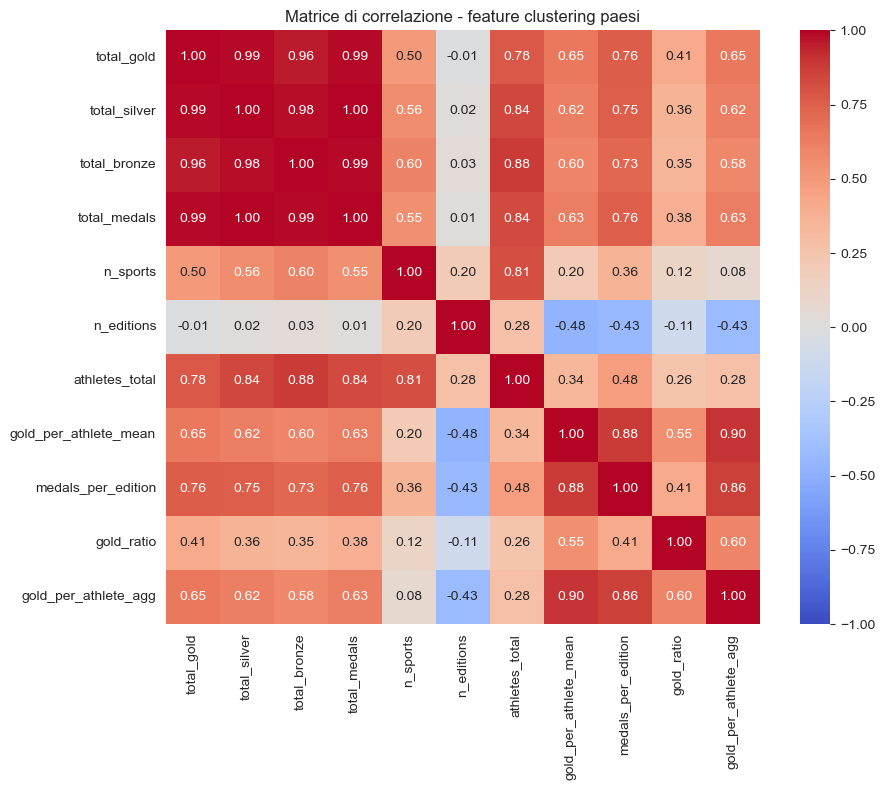

In [91]:
#Plotto la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matrice di correlazione - feature clustering paesi')
plt.tight_layout()
plt.show()

In [92]:
# In base alle correlazioni osservate, mantengo un sottoinsieme di 5 features per il clustering.
feat_for_clust = ['total_medals', 'gold_ratio', 'n_sports', 'gold_per_athlete_mean', 'n_editions']

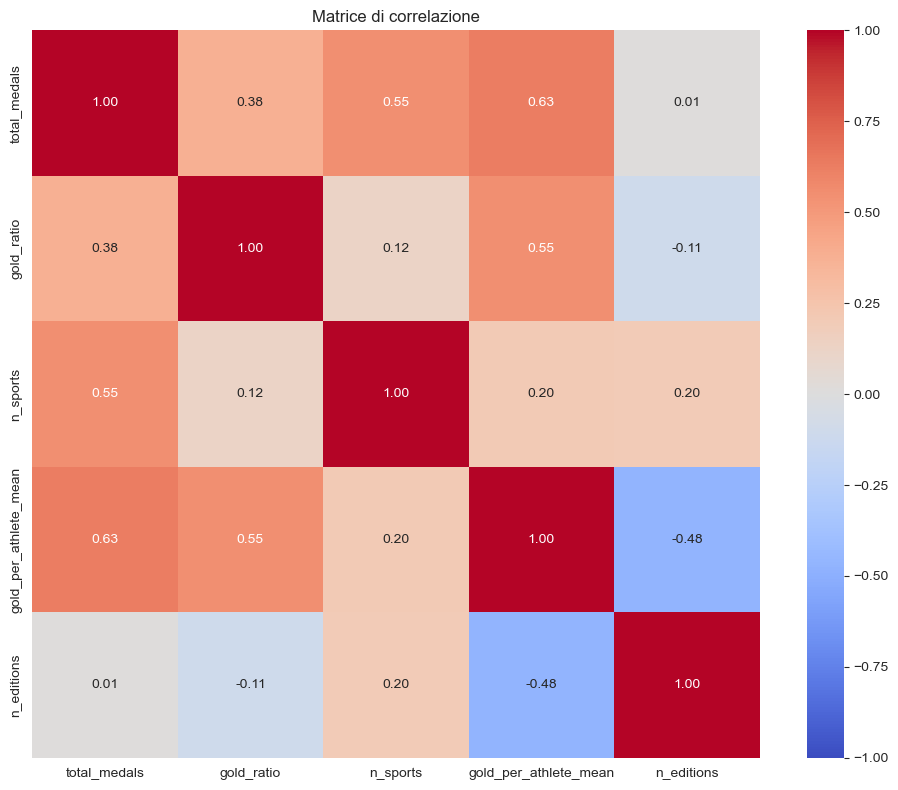

In [93]:
# Verifico nuovamente le correlazioni sulle features per il clustering
corr2 = df_country_profile[feat_for_clust].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

In [94]:
#Standardizzo le features per il clustering
X = df_country_profile[feat_for_clust]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [95]:
# valuto il clustering con diversi k per scegliere il migliore
kmin = 2
kmax = 10

krange = np.arange(kmin, kmax, 1)

results = {
    "sse": list(),
    "bss": list(),
    "silh": list()
}

for k in krange:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    sse, bss, silh = eval_clustering(X_scaled, labels)
    results["sse"].append(sse)
    results["bss"].append(bss)
    results["silh"].append(silh)

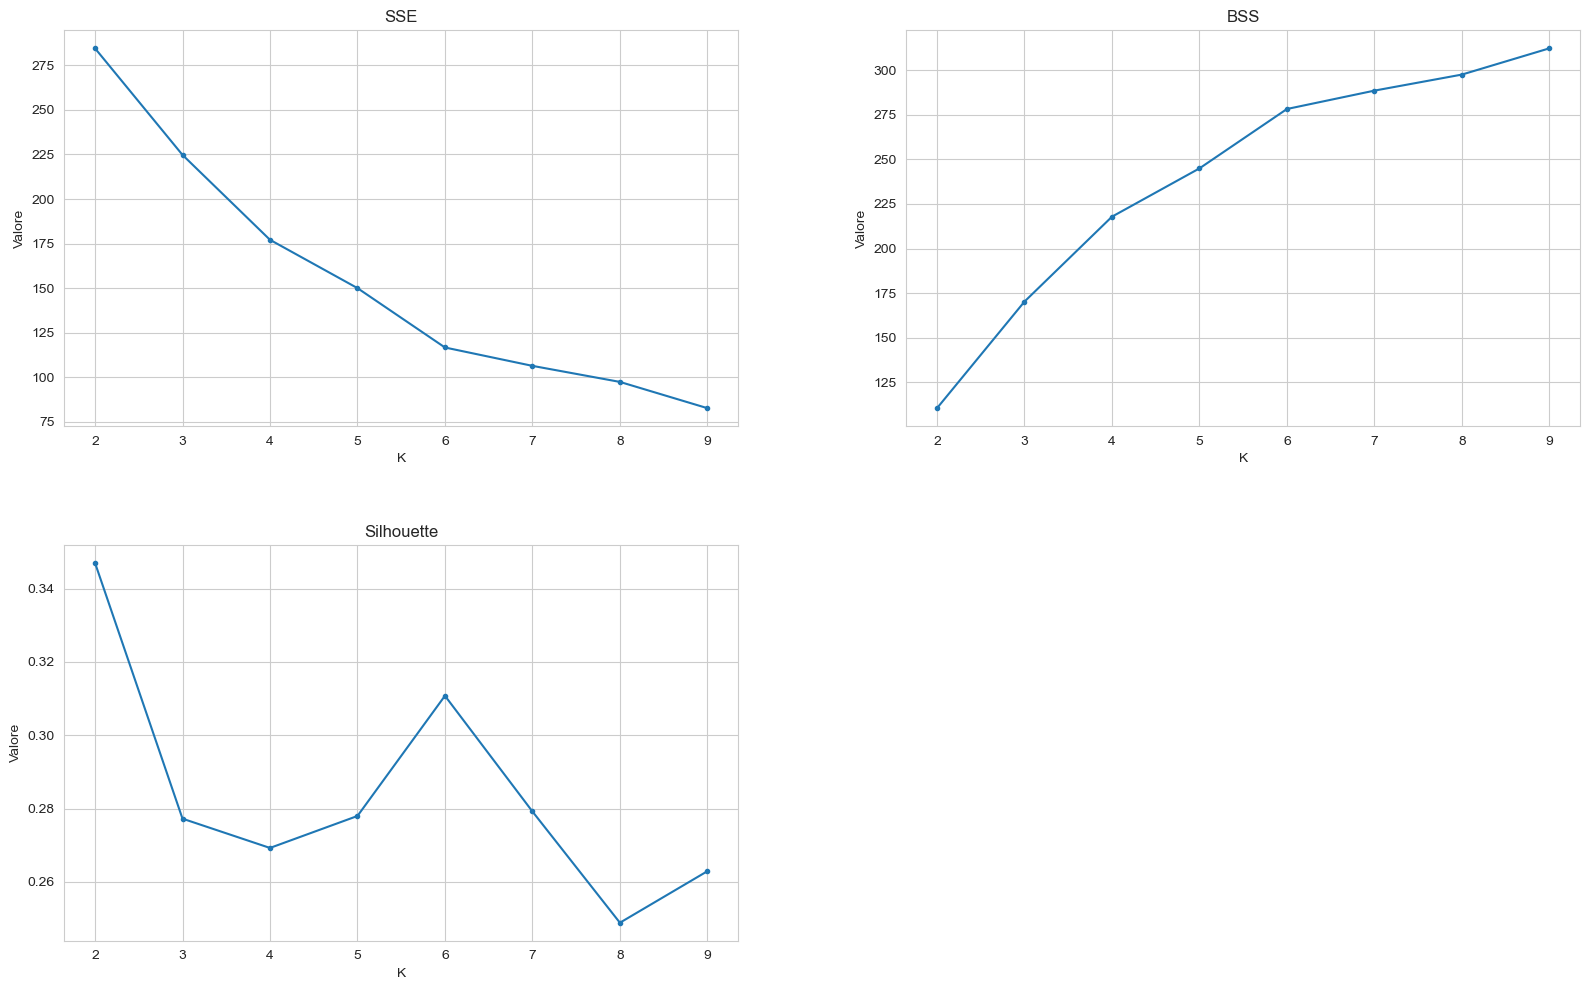

In [96]:
#plotto i risultati
metrics = ["sse", "bss", "silh"]
titles = ["SSE", "BSS", "Silhouette"]
nrows = 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10))
axes = axes.flatten()

for i, metrica in enumerate(metrics):
    ax = axes[i]
    ax.plot(krange, results[metrica], marker=".")
    ax.set_title(titles[i])
    ax.set_xlabel("K")
    ax.set_ylabel("Valore")
    ax.grid(True)

axes[3].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.25)
plt.show()

In [97]:
# Scelgo k = 6 perchè su questo valore individuo il gomito a scendere nel grafico della SSE, il gomito a salire in quello della BSS e il picco in quello della silhouette
n_clust_6 = KMeans(n_clusters=6,  random_state=42)
n_clust_6.fit(X_scaled)
df_country_profile['cluster_k6'] = n_clust_6.labels_

In [98]:
#Numero di istanze in ogni cluster
labels, sizes = np.unique(n_clust_6.labels_, return_counts=True)
for l, s in zip(labels, sizes):
    print("Cluster %s: %d (%.2f)" % (l, s, s / len(X)))

Cluster 0: 20 (0.25)
Cluster 1: 5 (0.06)
Cluster 2: 15 (0.19)
Cluster 3: 13 (0.16)
Cluster 4: 1 (0.01)
Cluster 5: 25 (0.32)


In [99]:
#Rendo uniformi i colori per i cluster nei vari grafici
cluster_colors = {
    'Cluster 0': '#4c78a8',
    'Cluster 1': '#f58518',
    'Cluster 2': '#e45756',
    'Cluster 3': '#b279a2',
    'Cluster 4': '#54a24b',
    'Cluster 5': '#eeca3b',
}
color_scale = alt.Scale(
    domain=list(cluster_colors.keys()),
    range=list(cluster_colors.values())
)

In [100]:
# Visualizzo i centroidi dei cluster tramite coordinate parallele
centroids = pd.DataFrame(
    n_clust_6.cluster_centers_,
    columns=feat_for_clust
)
centroids['cluster'] = [f'Cluster {i}' for i in range(len(centroids))]

centroids_long = centroids.melt(
    id_vars='cluster',
    value_vars=feat_for_clust,
    var_name='feature',
    value_name='valore'
)

alt.Chart(centroids_long).mark_line(point=True).encode(
    x=alt.X('feature:N', sort=feat_for_clust, title=None, axis=alt.Axis(labelAngle=0)),
    y=alt.Y('valore:Q', title='Valori'),
    color=alt.Color('cluster:N', title='Cluster', scale=color_scale),
    tooltip=['cluster', 'feature', 'valore']
).properties(
    width=500,
    height=300,
    title='Coordinate parallele — centroidi cluster'
).interactive()

alt.Chart(...)

In [101]:
#PCA per visualizzare i cluster
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = ['Cluster ' + str(c) for c in df_country_profile['cluster_k6'].values]
df_pca['country'] = df_country_profile['country'].values

alt.Chart(df_pca).mark_circle(size=80, opacity=0.6).encode(
    x=alt.X('PC1:Q', title='Prima componente principale'),
    y=alt.Y('PC2:Q', title='Seconda componente principale'),
    color=alt.Color('cluster:N', title='Cluster', scale=color_scale),
    tooltip=['country', 'cluster']
).properties(
    width=500,
    height=400,
    title='PCA - Clustering Paesi'
).interactive()

alt.Chart(...)

In [102]:
#Lista di Paesi appartenenti a ciasun cluster
for k in sorted(df_country_profile['cluster_k6'].unique()):
    sports = df_country_profile[df_country_profile['cluster_k6'] == k]['country'].tolist()
    print(f"\nCluster {k}:")
    print(sports)


Cluster 0:
['Azerbaijan', 'Belarus', 'Croatia', 'Czechia', 'Estonia', 'West Germany', 'Georgia', 'Kazakhstan', 'Latvia', 'Lithuania', 'North Korea', 'Russian Olympic Committee', 'South Africa', 'Slovenia', 'Serbia', 'Slovakia', 'Czechoslovakia', 'Ukraine', 'Uzbekistan', 'Yugoslavia']

Cluster 1:
['China', 'Unified Team', 'East Germany', 'Russian Federation', 'Soviet Union']

Cluster 2:
['Algeria', 'Bahamas', 'Dominican Republic', 'Ethiopia', 'Finland', 'Iran', 'Ireland', 'Jamaica', 'Kenya', 'Morocco', 'Norway', 'Thailand', 'Tunisia', 'Türkiye', 'Uganda']

Cluster 3:
['Armenia', 'Austria', 'Colombia', 'Egypt', 'Indonesia', 'India', 'Israel', 'Malaysia', 'Mongolia', 'Nigeria', 'Chinese Taipei', 'Trinidad and Tobago', 'Venezuela']

Cluster 4:
['United States']

Cluster 5:
['Argentina', 'Australia', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Cuba', 'Denmark', 'Spain', 'France', 'Great Britain', 'Germany', 'Greece', 'Hungary', 'Italy', 'Japan', 'South Korea', 'Mexico', 'Netherlands', 'New

## INTERPRETAZIONE CLUSTER

- Cluster 0, le ex repubbliche sovietiche e jugoslave + Germania Ovest, Sudafrica e Corea del Nord: principalmente Paesi che hanno preso parte a poche edizioni delle Olimpiadi e che hanno ottenuto performance medio-basse.
- Cluster 1, i giganti dalla storia discontinua: nonostante non abbiano una storia continuativa di partecipazione ai giochi olimpici (alcuni paesi non esistono nemmeno più), quando hanno partecipato hanno sempre ottenuto risultati straordinari — i valori più alti di gold_per_athlete_mean e gold_ratio tra tutti i cluster, segno di un dominio quasi assoluto nei periodi di attività
- Cluster 2, gli specialisti in alcuni sport: paesi presenti in quasi tutte le edizioni e che gareggiano in un numero limitato di sport ottenendo poche medaglie in totale ma con un'alta proporzione di ori, segno di estrema specializzazione.
- Cluster 3, i partecipanti diversificati ma poco performanti: paesi presenti in quasi tutte le edizioni olimpiche, con il volume di medaglie totali più basso tra tutti i cluster e la proporzione di ori sul totale più bassa in assoluto — quando salgono sul podio, lo fanno prevalentemente con argenti e bronzi, faticando soprattutto a conquistare l'oro.
- Cluster 4, gli Stati Uniti: paese con altissimo numero di medaglie totali e con medaglie d'oro alla pari con quelle del Cluster 1.  Si distingue inoltre per il numero di sport più alto tra tutti i cluster (il dominio statunitense non si concentra in poche discipline ma si estende trasversalmente a moltissimi sport diversi, a differenza del Cluster 1 dove il successo è più concentrato).
- Cluster 5, le potenze olimpiche consolidate: il clsuter più numeroso che contiene Paesi con una solida tradizione olimpica, che partecipano in quasi tutte le categorie sportive ottenendo medaglie distribuite su molti sport gli sport.

## Paesi e sport

In [103]:
print(df_success.shape)
print(df_success.head())

(3291, 6)
  country_noc      sport  success_score_mean  total_golds  total_athletes  \
0         AFG  Athletics                 0.0          0.0              12   
1         AFG     Boxing                 0.0          0.0               5   
2         AFG       Judo                 0.0          0.0               3   
3         AFG   Shooting                 0.0          0.0               1   
4         AFG   Swimming                 0.0          0.0               1   

   gold_per_athletes  
0                0.0  
1                0.0  
2                0.0  
3                0.0  
4                0.0  


In [104]:
#Creo una matrice paese x sport, dove ogni cella contiene l'efficienza (ori/atleti) del paese in quello sport
pivot = df_success.pivot_table(
    index='country_noc',
    columns='sport',
    values='gold_per_athletes',
    fill_value=0
)

print(pivot.shape)
print(pivot.head())

(144, 55)
sport        3x3 Basketball  Archery  Artistic Gymnastics  Artistic Swimming  \
country_noc                                                                    
AFG                     0.0      0.0                  0.0                0.0   
AHO                     0.0      0.0                  0.0                0.0   
ALG                     0.0      0.0                  0.0                0.0   
ARG                     0.0      0.0                  0.0                0.0   
ARM                     0.0      0.0                  0.0                0.0   

sport        Athletics  Badminton  Baseball  Basketball  Basque pelota  \
country_noc                                                              
AFG            0.00000        0.0       0.0    0.000000            0.0   
AHO            0.00000        0.0       0.0    0.000000            0.0   
ALG            0.02963        0.0       0.0    0.000000            0.0   
ARG            0.00000        0.0       0.0    0.166667    

In [105]:
#Mantengo solo i paesi già selezionati nel clustering precedente (almeno 10 medaglie totali), per coerenza
countries_to_keep = df_country_profile['country_noc'].tolist()
pivot = pivot[pivot.index.isin(countries_to_keep)]
print(pivot.shape)

(79, 55)


In [106]:
pivot

sport,3x3 Basketball,Archery,Artistic Gymnastics,Artistic Swimming,Athletics,Badminton,Baseball,Basketball,Basque pelota,Beach Volleyball,...,Taekwondo,Tennis,Trampolining,Triathlon,Volleyball,Water Polo,Waterskiing,Weightlifting,Wrestling,Wushu
country_noc,,,,,,,,,,,,,,,,,,,,,
ALG,0.0,0.000000,0.000000,0.000000,0.029630,0.0,0.000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
ARG,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000,0.166667,0.0,0.000000,...,0.125000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
ARM,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.037736,0.0
AUS,0.0,0.020000,0.000000,0.000000,0.014876,0.0,0.000,0.000000,0.0,0.071429,...,0.030303,0.017544,0.0,0.028571,0.000000,0.052632,0.0,0.015625,0.000000,0.0
AUT,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.058824,0.000000,0.000000,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URS,0.0,0.052632,0.583333,0.000000,0.096234,0.0,0.000,0.444444,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.583333,0.333333,0.0,0.549020,0.419643,0.0
USA,1.0,0.119403,0.127273,0.294118,0.098938,0.0,0.125,0.800000,0.0,0.304348,...,0.069767,0.164706,0.0,0.029412,0.166667,0.157895,0.0,0.009615,0.131148,0.0
UZB,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000,0.000000,0.0,0.000000,...,0.066667,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.074074,0.033333,0.0


In [107]:
#Verifico quanti valori della matrice sono zero (paese non ha mai vinto ori in quello sport)
zeros = (pivot == 0).sum().sum()
total = pivot.shape[0] * pivot.shape[1]
print(f"Valori zero: {zeros}/{total} ({zeros/total*100:.1f}%)")

Valori zero: 3643/4345 (83.8%)


In [108]:
# Trasformazione logaritmica per ridurre l'effetto dei valori estremi e standardizzazione
pivot_log = np.log1p(pivot)
X_scaled2 = StandardScaler().fit_transform(pivot_log)

In [109]:
#Trasformo la matrice in binaria (1 = il paese ha vinto almeno un oro in quello sport, 0 = mai),
#per passare a un clustering basato su presenza/assenza invece che su intensità
sport_cols = pivot.columns.tolist()
pivot_binary = (pivot[sport_cols] > 0).astype(int)

In [110]:
#Calcolo la distanza di Jaccard tra i paesi
distances = pdist(pivot_binary.values, metric='jaccard')
dist_matrix = squareform(distances)
print(dist_matrix.shape)

(79, 79)


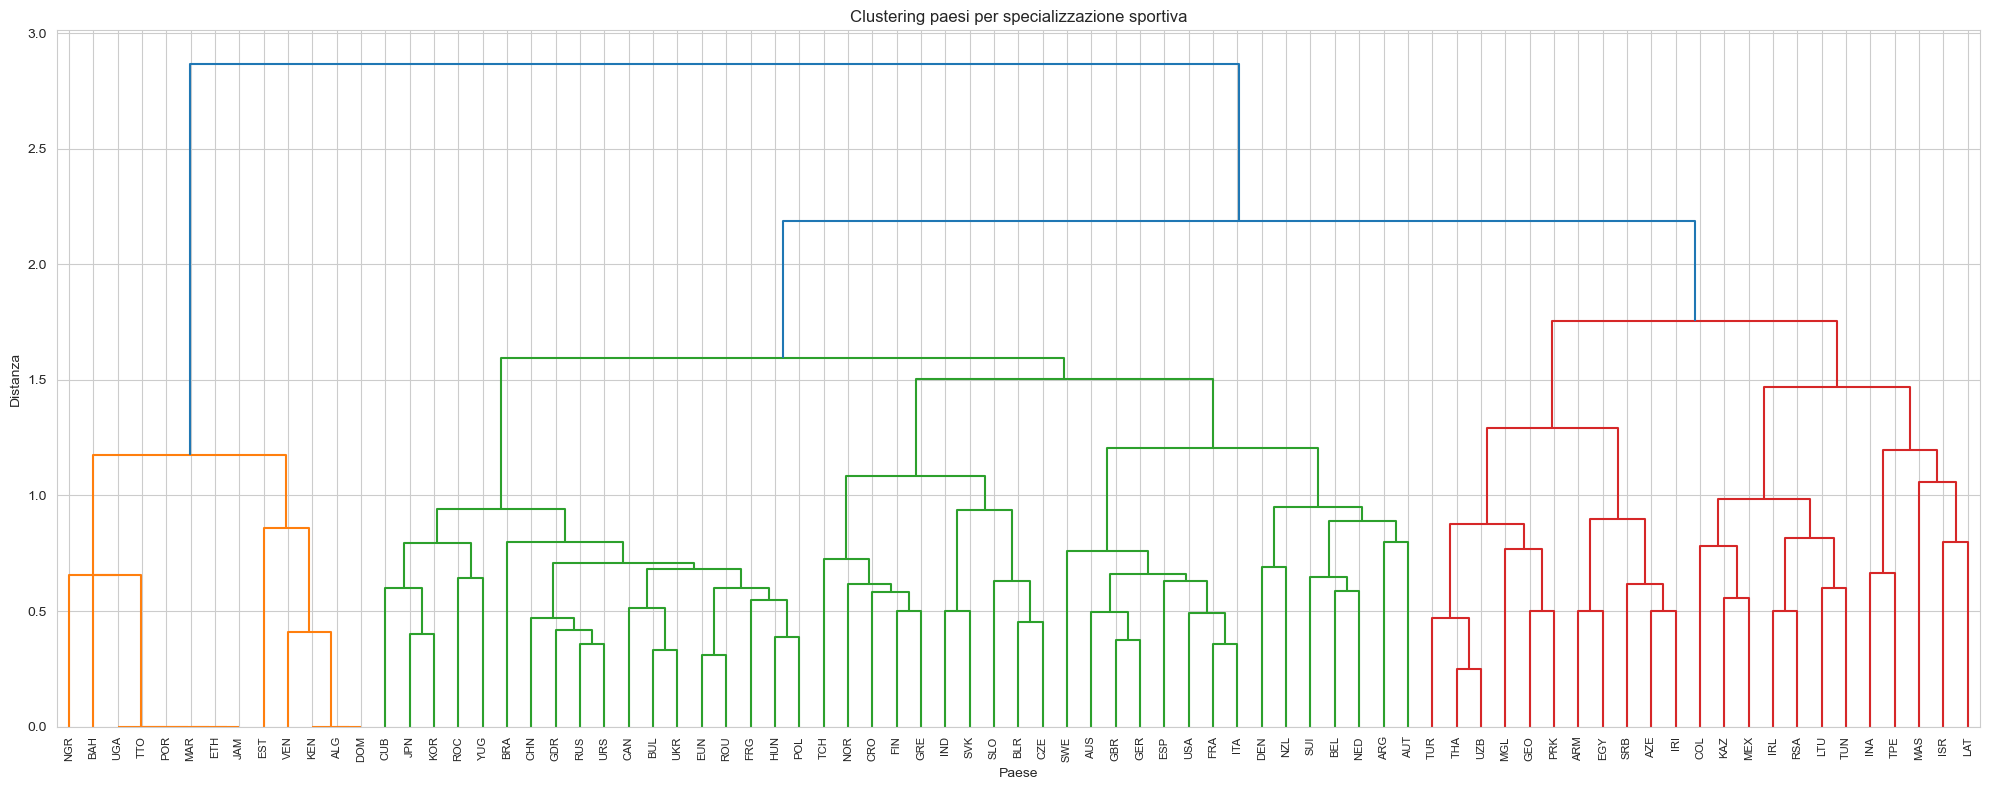

In [111]:
#Clustering gerarchico e dendrogramma per scegliere dove tagliare
linkage_matrix = linkage(distances, method='ward')

plt.figure(figsize=(20, 8))
dendrogram(
    linkage_matrix,
    labels=pivot_binary.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title('Clustering paesi per specializzazione sportiva')
plt.xlabel('Paese')
plt.ylabel('Distanza')
plt.tight_layout()
plt.show()

In [112]:
# In base alla visualizzazione del dendogramma hi deciso di tagliarlo a distanza 1.5
labels_hier = fcluster(linkage_matrix, t=1.5, criterion='distance')
pivot_binary['cluster_hier'] = labels_hier
print(pd.Series(labels_hier).value_counts())

2    18
4    15
1    13
6    12
5    11
3    10
Name: count, dtype: int64


In [113]:
#Paesi per cluster gerarchico
df_results_hier = pd.DataFrame({
    'country_noc': pivot_binary.index,
    'cluster_hier': labels_hier
})

df_results_hier = df_results_hier.merge(
    df_country_profile[['country_noc', 'country']],
    on='country_noc',
    how='left'
)

for k in sorted(df_results_hier['cluster_hier'].unique()):
    countries = df_results_hier[df_results_hier['cluster_hier'] == k]['country'].tolist()
    print(f"\nCluster {k} ({len(countries)} paesi):")
    for c in sorted(countries):
        print(f"  - {c}")


Cluster 1 (13 paesi):
  - Algeria
  - Bahamas
  - Dominican Republic
  - Estonia
  - Ethiopia
  - Jamaica
  - Kenya
  - Morocco
  - Nigeria
  - Portugal
  - Trinidad and Tobago
  - Uganda
  - Venezuela

Cluster 2 (18 paesi):
  - Brazil
  - Bulgaria
  - Canada
  - China
  - Cuba
  - East Germany
  - Hungary
  - Japan
  - Poland
  - Romania
  - Russian Federation
  - Russian Olympic Committee
  - South Korea
  - Soviet Union
  - Ukraine
  - Unified Team
  - West Germany
  - Yugoslavia

Cluster 3 (10 paesi):
  - Belarus
  - Croatia
  - Czechia
  - Czechoslovakia
  - Finland
  - Greece
  - India
  - Norway
  - Slovakia
  - Slovenia

Cluster 4 (15 paesi):
  - Argentina
  - Australia
  - Austria
  - Belgium
  - Denmark
  - France
  - Germany
  - Great Britain
  - Italy
  - Netherlands
  - New Zealand
  - Spain
  - Sweden
  - Switzerland
  - United States

Cluster 5 (11 paesi):
  - Armenia
  - Azerbaijan
  - Egypt
  - Georgia
  - Iran
  - Mongolia
  - North Korea
  - Serbia
  - Thailand
  - 

In [114]:
# Calcolo, per ogni cluster, i 10 sport in cui la percentuale di paesi che vince almeno un oro è più alta
for k in sorted(df_results_hier['cluster_hier'].unique()):
    mask = pivot_binary['cluster_hier'] == k
    top_sports = pivot_binary[mask][sport_cols].mean().nlargest(10)
    print(f"\nCluster {k} — top 10 sport:")
    print(top_sports)


Cluster 1 — top 10 sport:
sport
Athletics              1.000000
Boxing                 0.307692
Fencing                0.153846
Cycling Track          0.076923
Football               0.076923
Sailing                0.076923
3x3 Basketball         0.000000
Archery                0.000000
Artistic Gymnastics    0.000000
Artistic Swimming      0.000000
dtype: float64

Cluster 2 — top 10 sport:
sport
Athletics              0.944444
Shooting               0.944444
Swimming               0.944444
Wrestling              0.944444
Artistic Gymnastics    0.888889
Boxing                 0.888889
Weightlifting          0.833333
Canoe Sprint           0.777778
Judo                   0.722222
Fencing                0.666667
dtype: float64

Cluster 3 — top 10 sport:
sport
Athletics        1.0
Shooting         1.0
Rowing           0.7
Weightlifting    0.6
Canoe Slalom     0.4
Canoe Sprint     0.4
Judo             0.4
Sailing          0.4
Tennis           0.4
Wrestling        0.4
dtype: float64

Clust

## INTERPRETAZIONE CLUSTER

- Cluster 1, gli specialisti di atletica leggera: è il cluster più nettamente monotematico con specializzazione sportiva in atlerica al 100%. C'è un 31% sul pugilato e un 15% nella scherma, il resto è vicino allo 0. Ad eccezione di Estonia, Portogallo e Venezuela, vi appartengono paesi africani e caraibici (Algeria, Bahamas, Dominican Republic, Ethiopia, Jamaica, Kenya, Morocco, Nigeria, Trinidad and Tobago, Uganda) che vincono meedaglie in atletica. C'è quindi massima specializzazione e minima diversificazione.
- Cluster 2, le potenze multidisciplinari: quasi onnipresenti in moltissimi sport (Atletica, Tiro, Nuoto, Lotta tutti al 94%, Ginnastica e Pugilato all'89%, Sollevamento pesi all'83%). Il profilo più diversificato e dominante in assoluto tra tutti i sei cluster; questi paesi costruiscono il proprio successo olimpico su una base ampia e trasversale di sport, dalle gare di forza a quelle tecniche. Coerente con l'eredità delle superpotenze della Guerra Fredda olimpica (blocco sovietico, Germania Est/Ovest) affiancate da Brasile, Canada, Cina, Cuba, Giappone, Poonia, Romania e Corea del Sud, che hanno costruito sistemi sportivi altrettanto ampi e capillari.
- Cluster 3, le piccole-medie tradizioni olimpiche: Atletica e Tiro al 100%, Canottaggio al 70%, Sollevamento pesi al 60%. Un profilo che ricorda il Cluster 2 per ampiezza ma con intensità minore — buona tradizione sportiva diffusa, prevalentemente paesi di dimensioni medio-piccole (ex repubbliche del blocco sovietico/jugoslavo più Grecia e alcuni paesi nordici ed europei), con l'eccezione dell'India, che pur essendo un Paese più grande e popoloso, condivide con questo gruppo un profilo di performance olimpica relativamente contenuta e diversificata.
- Cluster 4, le potenze tecniche diversificate: Ciclismo su pista e Vela all'87%, Ciclismo su strada all'80%, Nuoto all'80%. Il profilo più orientato verso sport "tecnici/infrastrutturali" (ciclismo, vela, canottaggio) che richiedono investimenti e tradizione consolidata; il classico profilo delle economie sviluppate con forte cultura sportiva olimpica, prevalentemente europee e nordamericane (Austria, Belgium, Denmark, France, Germany, Great Britain, Italy, Netherlands, Spain, Sweden, Switzerland, United States), con Argentina e Australia e Nuova Zelanda come eccezioni rispettivamente sudamericana e oceaniche del gruppo.
- Cluster 5, gli specialisti in sport da combattimento: Lotta all'82%, Taekwondo e Sollevamento pesi al 55%, Pugilato e Judo al 45%. Specializzazione molto netta sugli sport da combattimento e di forza — coerente con la tradizione sportiva dell'Asia Centrale, Caucaso e Medio Oriente, dove questi sport hanno radici culturali profonde, con Egitto, Serbia e Thailandia come eccezioni geografiche che condividono comunque questo profilo di specializzazione nel combattimento. Oltre ai tre Paesi già menzionati, fanno parte di questo cluster paesi come Armenia, Azerbaijan, Georgia, Iran, Mongolia, North Korea, Türkiye, Uzbekistan.
- Cluster 6, i partecioanti dal profilo eterogeneo: Atletica e Nuoto al 50%, valori più contenuti su tutto il resto (Sollevamento pesi 33%, Pugilato 25%). A differenza degli altri cluster, qui non c'è un dominio netto in nessuno sport; la presenza in Atletica e Nuoto riflette più la loro natura di sport universali che una vera specializzazione, mentre il resto del profilo è disperso su molte discipline diverse senza un pattern dominante chiaro. Fanno parte di questo cluster Paesi come Chinese Taipei, Colombia, Indonesia, Ireland, Israel, Kazakhstan, Latvia, Lithuania, Malaysia, Mexico, South Africa, Tunisia.
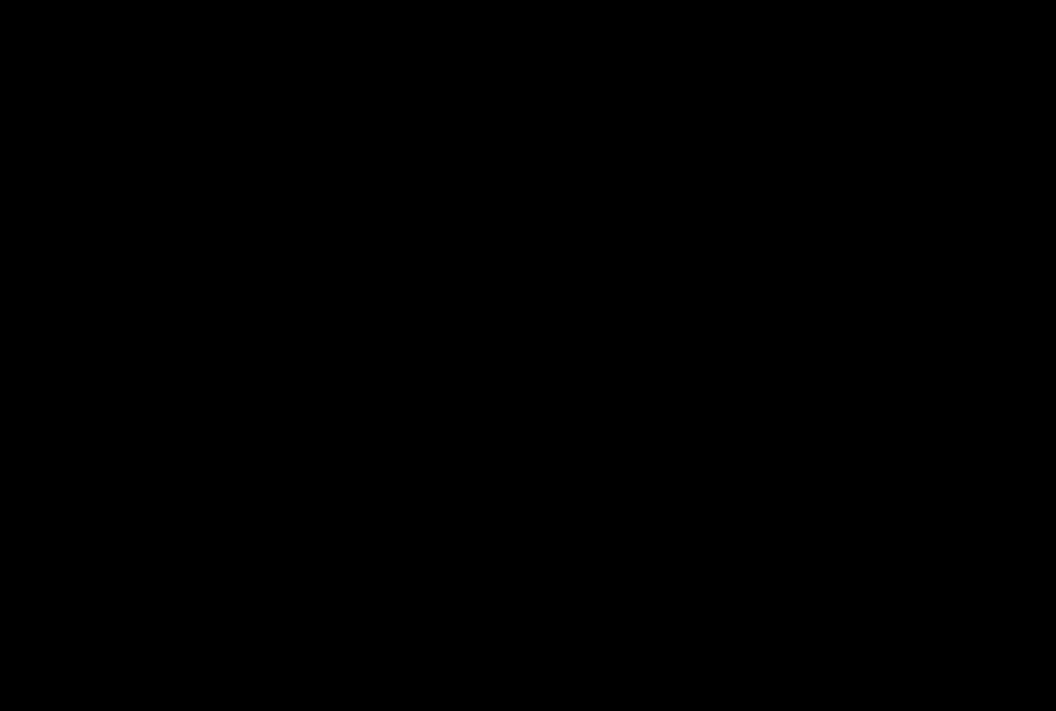
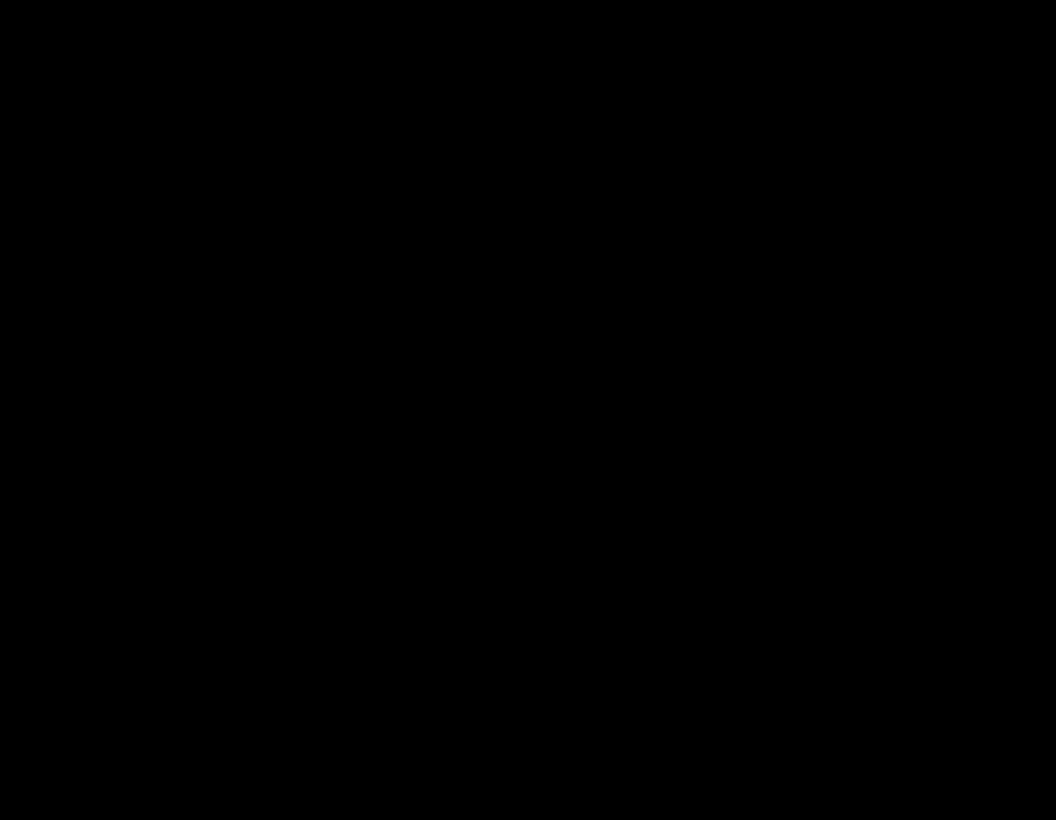
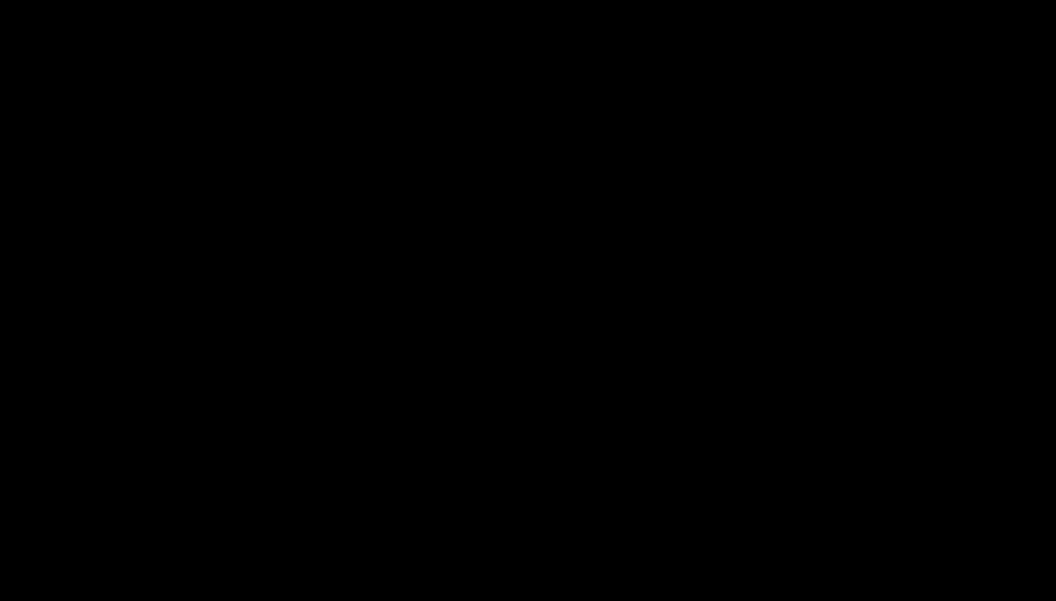
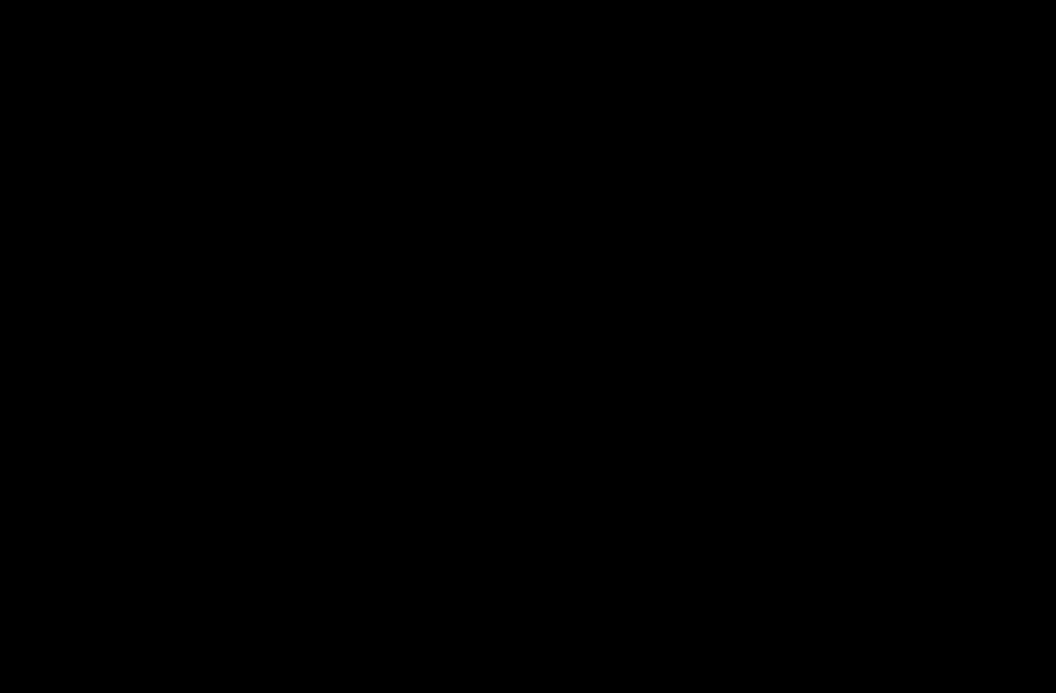

In [115]:
# Grafico interattivo in cui si può scegliere un Paese e visualizzare i 5 sport in cui ha vinto più ori e più medaglie totali

In [116]:
country_sport_totals = df_macro.groupby(['country', 'sport']).agg(
    total_gold=('gold', 'sum'),
    total_medals=('total_medals', 'sum')
).reset_index()

top5_gold_by_country = (
    country_sport_totals[country_sport_totals['total_gold'] > 0]
    .sort_values(['country', 'total_gold'], ascending=[True, False])
    .groupby('country')
    .head(5)
)

top5_medals_by_country = (
    country_sport_totals[country_sport_totals['total_medals'] > 0]
    .sort_values(['country', 'total_medals'], ascending=[True, False])
    .groupby('country')
    .head(5)
)

#countries_list = sorted(df_country_profile['country'].unique().tolist())
countries_list = sorted(df_macro['country'].unique().tolist())

country_dropdown = alt.binding_select(options=countries_list, name='Paese: ')
country_select = alt.selection_point(fields=['country'], bind=country_dropdown, value=countries_list[0])

In [117]:
gold_chart = alt.Chart(top5_gold_by_country).mark_bar().encode(
    x=alt.X('total_gold:Q', title='Ori vinti'),
    y=alt.Y('sport:N', title='Sport', sort='-x'),
    color=alt.value('#f58518'),
    tooltip=['sport', 'total_gold']
).add_params(
    country_select
).transform_filter(
    country_select
).properties(
    width=400,
    height=250,
    title='Top 5 sport per ori vinti',
    padding={'left': 100, 'top': 5, 'right': 5, 'bottom': 5}
)
gold_chart

alt.Chart(...)

In [118]:
medals_chart = alt.Chart(top5_medals_by_country).mark_bar().encode(
    x=alt.X('total_medals:Q', title='Medaglie totali vinte', axis=alt.Axis(tickCount=30)),
    y=alt.Y('sport:N', title='Sport', sort='-x'),
    color=alt.value('#4c78a8'),
    tooltip=['sport', 'total_medals']
).add_params(
    country_select
).transform_filter(
    country_select
).properties(
    width=400,
    height=250,
    title='Top 5 sport per medaglie totali',
    padding={'left': 100, 'top': 5, 'right': 5, 'bottom': 5}
)
medals_chart

alt.Chart(...)